# **Error Analysis - Video Games**


Note: the predictions get retourned as BPR loss. As consequence, the predictions are not in the range of 0 to 1. To interpret them further, we need to convert them to the range of 0 to 1. Use sigmoid function.

Imports

In [189]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import networkx as nx
import itertools
from collections import defaultdict


Helper Functions

In [246]:


def draw_ego_hops(G, center_node, hops=2):
    """
    Draw the subgraph of G containing center_node plus all nodes
    at distance ≤ hops (first- and second-degree neighbors).
    """
    # 1) compute distances up to `hops`
    lengths = nx.single_source_shortest_path_length(G, center_node, cutoff=hops)
    # `lengths` maps node → distance (0 for center, 1 for neighbors, 2 for 2-hop)
    
    # 2) induce the subgraph
    nodes_within = list(lengths.keys())
    H = G.subgraph(nodes_within).copy()
    
    # 3) draw
    pos = nx.spring_layout(H)  # force-directed layout
    plt.figure(figsize=(8,8))
    
    # draw nodes, coloring by distance
    node_colors = [lengths[n] for n in H.nodes()]
    nx.draw_networkx_nodes(
        H, pos,
        node_size=300,
        cmap=plt.cm.viridis,
        node_color=node_colors,
        vmin=0, vmax=hops
    )
    # highlight edges connected to center node
    center_edges = list(H.edges(center_node))
    nx.draw_networkx_edges(
        H, pos,
        edgelist=center_edges,
        width=2.5,
        alpha=0.8,
        edge_color='red'
    )
    # draw edges
    nx.draw_networkx_edges(H, pos, alpha=0.5)
    
    # highlight the center node with a red border
    nx.draw_networkx_nodes(
        H, pos,
        nodelist=[center_node],
        node_size=500,
        edgecolors='red',
        linewidths=2,
    )
    
    # labels - adjust font size and add bbox for better readability
    labels = nx.draw_networkx_labels(
        H, pos,
        font_size=8,
        font_weight='bold',
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1),
        horizontalalignment='center'
    )
    
    plt.title(f"Ego-graph of {center_node} (hops≤{hops})")
    plt.axis('off')
    plt.show()

# test use sigmoid function
def process_prediction(prediction_df):
    def sigmoid(x):
        return 1 / (1 + np.exp(-x))
    
    prediction_df["prediction_sigmoid"] = sigmoid(prediction_df['prediction'])
    prediction_df["prediction_value"] = (prediction_df["prediction_sigmoid"] > 0.5).astype(int) # 1 if sigmoid > 0.5, otherwise 0
    return prediction_df

def count_hits(error_df):
    """
    Count hits and calculate accuracy metrics for prediction results.
    
    Args:
        error_df: DataFrame containing prediction results with 'prediction_value' and 'actual' columns
        
    Returns:
        DataFrame: The input DataFrame with additional columns for prediction metrics
    """
    # Add prediction correctness column
    error_df["prediction_correct"] = error_df["prediction_value"] == error_df["actual"]
    
    # Add positive and negative prediction columns
    error_df["prediction_positive"] = error_df["prediction_value"] == 1
    error_df["prediction_negative"] = error_df["prediction_value"] == 0

    
    # Print accuracy
    print(f"Accuracy in test set: {error_df['prediction_correct'].sum() / len(error_df)}")
    
    return error_df

def connect_parents(error_df, relation_df):
    error_df_item = error_df.copy()
    # Select only necessary columns from relation_df to avoid merge conflicts
    relation_subset = relation_df[['head', 'tail']].copy()

    # merge first level parent
    error_df_item = error_df_item.merge(
        relation_subset,
        left_on="item_id",
        right_on="head",
        how="left"
    ).rename(columns={"tail": "first_level_parent"})
    error_df_item.drop(columns=["head"], inplace=True) # Drop the added 'head' column

    # merge second level parent
    error_df_item = error_df_item.merge(
        relation_subset,
        left_on="first_level_parent",
        right_on="head",
        how="left"
    ).rename(columns={"tail": "second_level_parent"})
    error_df_item.drop(columns=["head"], inplace=True) # Drop the added 'head' column

    # merge third level parent
    error_df_item = error_df_item.merge(
        relation_subset,
        left_on="second_level_parent",
        right_on="head",
        how="left"
    ).rename(columns={"tail": "third_level_parent"})
    error_df_item.drop(columns=["head"], inplace=True) # Drop the added 'head' column

    # merge fourth level parent
    error_df_item = error_df_item.merge(
        relation_subset,
        left_on="third_level_parent",
        right_on="head",
        how="left"
    ).rename(columns={"tail": "fourth_level_parent"})
    error_df_item.drop(columns=["head"], inplace=True) # Drop the added 'head' column

    return error_df_item


def map_ids_to_entities(df, mapping_df, df_type:str):
    if df_type == "relation":
        df["head"] = df["head"].map(mapping_df.set_index("id")["entity"])
        df["tail"] = df["tail"].map(mapping_df.set_index("id")["entity"])
    elif df_type == "error":
        df["item_id"] = df["item_id"].map(mapping_df.set_index("id")["entity"])
        df["user_id"] = df["user_id"].map(mapping_df.set_index("id")["entity"])
    return df



Parameters

In [247]:
# Set the desired data path, dataset name and model technique here
# Example: Use the 'amazon-All_Beauty' dataset located two levels up in 'data'
DATASETS = ["Books", "amazon-All_Beauty", "amazon-Video_Games","Last-FM"]
# Set the desired data path, dataset name and model technique here
# Example: Use the 'amazon-All_Beauty' dataset located two levels up in 'data'
MODEL_TECHNIQUES = ["all-MiniLM-L6-v2","intfloat/multilingual-e5-large-instruct","Alibaba-NLP/gte-Qwen2-1.5B-instruct","gemma3", "ner","baseline"]


Relationship prediction metrics to n_hops

In [250]:
# Set the desired data path, dataset name and model technique here
# Example: Use the 'amazon-All_Beauty' dataset located two levels up in 'data'
DATASETS = ["Books", "amazon-All_Beauty", "amazon-Video_Games","Last-FM"]
DATASET = DATASETS[2]
EXPERIMENT_NAME = "#1"
current_dir = os.getcwd()
project_root = os.path.dirname(os.path.dirname(os.path.dirname(current_dir)))


METRICS_PATH = os.path.join(project_root,"data", 'experiments',EXPERIMENT_NAME,DATASET)

N_HOPS = ["3","5","7","9"]
three_hops  = pd.read_csv(f"{METRICS_PATH}/3_acc_comparison_df.csv")
five_hops  = pd.read_csv(f"{METRICS_PATH}/5_acc_comparison_df.csv")
seven_hops  = pd.read_csv(f"{METRICS_PATH}/7_acc_comparison_df.csv")
nine_hops  = pd.read_csv(f"{METRICS_PATH}/9_acc_comparison_df.csv") 


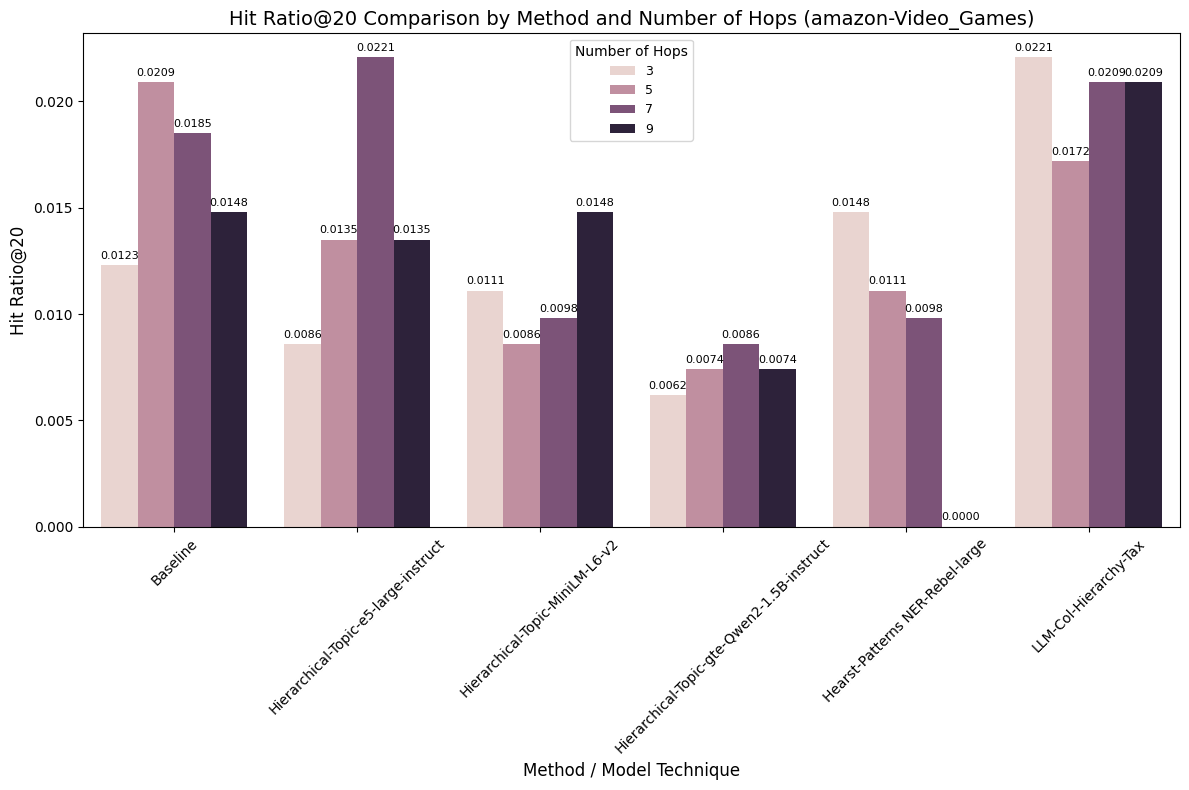

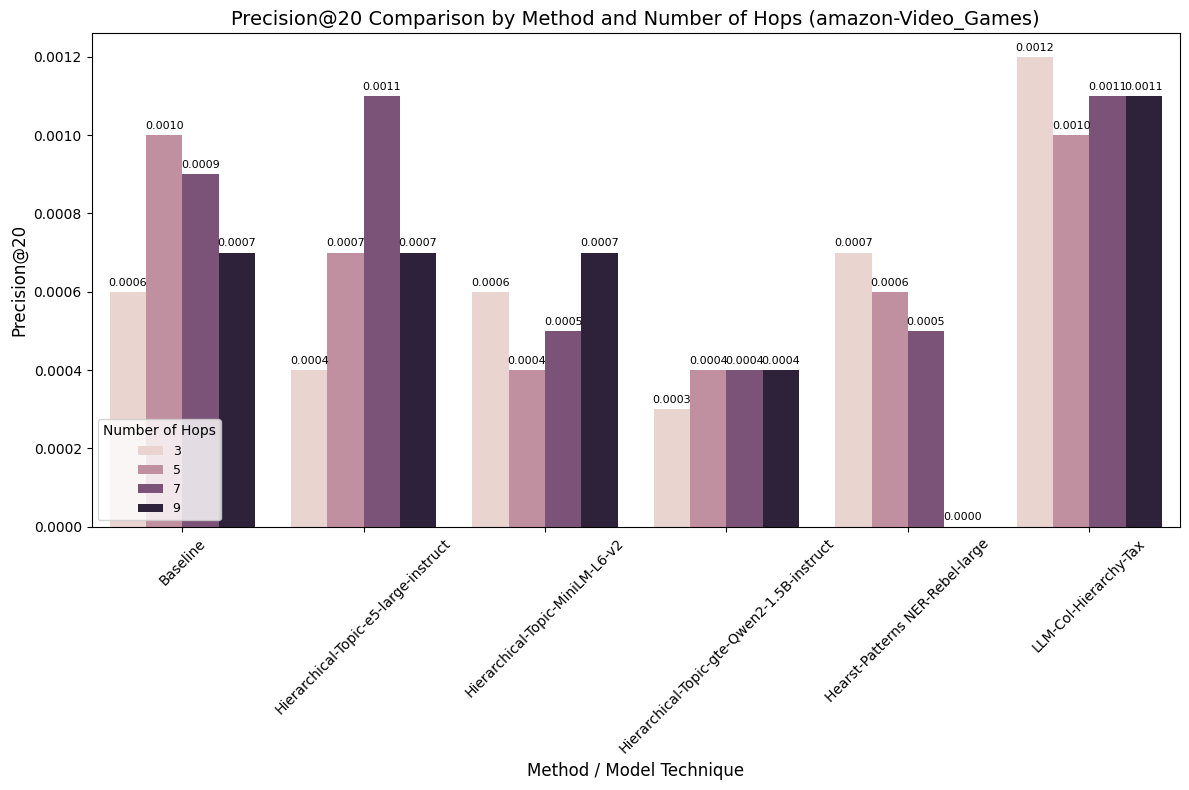

In [251]:
# make multiplot
# metric hit ratio
# bar group by model technique
# bars in group group by n_hops



# Add n_hops column to each dataframe
three_hops['n_hops'] = 3
five_hops['n_hops'] = 5
seven_hops['n_hops'] = 7
nine_hops['n_hops'] = 9

# Concatenate the dataframes
all_hops_df = pd.concat([three_hops, five_hops, seven_hops, nine_hops], ignore_index=True)

# --- Plot 1: Hit Ratio @ 20 ---
plt.figure(figsize=(12, 8)) # Adjust figure size as needed
ax1 = sns.barplot(data=all_hops_df, x='Method', y='Hit_Ratio@20', hue='n_hops')
ax1.set_xlabel('Method / Model Technique', fontsize=12)
ax1.set_ylabel('Hit Ratio@20', fontsize=12)
ax1.set_title(f'Hit Ratio@20 Comparison by Method and Number of Hops ({DATASET})', fontsize=14)
ax1.tick_params(axis='x', rotation=45, labelsize=10) # Rotate x-axis labels
ax1.tick_params(axis='y', labelsize=10) # Set y-axis label size
# Add value labels on top of bars
for container in ax1.containers:
    ax1.bar_label(container, fmt='%.4f', fontsize=8, padding=3)
ax1.legend(title='Number of Hops', title_fontsize='10', fontsize='9', loc='best') # Add legend

# Adjust layout and show the first plot
plt.tight_layout()
plt.show()


# --- Plot 2: Precision @ 20 ---
plt.figure(figsize=(12, 8)) # Adjust figure size as needed
ax2 = sns.barplot(data=all_hops_df, x='Method', y='Precision@20', hue='n_hops')
ax2.set_xlabel('Method / Model Technique', fontsize=12)
ax2.set_ylabel('Precision@20', fontsize=12)
ax2.set_title(f'Precision@20 Comparison by Method and Number of Hops ({DATASET})', fontsize=14)
ax2.tick_params(axis='x', rotation=45, labelsize=10) # Rotate x-axis labels
ax2.tick_params(axis='y', labelsize=10) # Set y-axis label size
# Add value labels on top of bars
for container in ax2.containers:
    ax2.bar_label(container, fmt='%.4f', fontsize=8, padding=3)
ax2.legend(title='Number of Hops', title_fontsize='10', fontsize='9', loc='lower left') # Add legend

# Adjust layout and show the second plot
plt.tight_layout()
plt.show()


Interpretation of Performance Metrics vs. Hops (Video Games Dataset)
 
 The plots above visualize two common recommendation system evaluation metrics, Hit Ratio@20 and Precision@20, across different knowledge graph construction methods and varying numbers of hops (graph traversal depth) used during recommendation generation.
 
Metric Definitions:
 
 *   **Hit Ratio@20 (HR@20):** measures the proportion of users for whom the item they actually interacted with (the "hit") was present within the top 20 recommended items. A higher HR@20 indicates that the model is better at including the relevant item somewhere in its top recommendations.
 *   **Precision@20 (P@20):** measures, on average, the proportion of items in the top 20 recommendation list that are actually relevant (i.e., the item the user interacted with). In leave-one-out evaluation (common here), since there's only one relevant item per user in the test set, Precision@20 is calculated as (Number of Hits in Top 20) / 20. It essentially reflects the hit rate scaled by the list size. A higher P@20 means the recommendation list is more concentrated with relevant items at the top.
 
 Performance Analysis:
 
 1.  **Overall Performance:**
     *   The `LLM-Col-Hierarchy-Tax` method consistently achieves the highest performance across most hop counts for both Hit Ratio@20 (around 0.0221) and Precision@20 (around 0.0012).
     *   The `Baseline`, `Hearst-Patterns NER-Rebel-large`, and `Hierarchical-Topic-e5-large-instruct` methods show very similar, moderate performance, achieving an HR@20 of roughly 0.0148 and P@20 of 0.0007.
     *   The `Hierarchical-Topic-e5-large-instruct methods exhibit with second best performance compared to the others, with HR@20 around 0.0221 and P@20 around 0.0012, but is not as consistent as the LLM-Col-Hierarchy-Tax method.
     * Intrestingy the method 'all-MiniLM-L6-v2', 'e5-large-instruct', 'gte-Qwen2-1.5B-instruct' have the same base algorithm, but vary noticably in performance. The e5-large-instruct method has the best performance for 7 hops, but is not as consistent as the LLM-Col-Hierarchy-Tax method.
 
 2.  **Impact of Number of Hops:**
     *   A key observation from both plots for the Video Games dataset is that the **number of hops (ranging from 3 to 9) appears to have an impact on the performance** of any given method.
     * For each individual method, the Hit Ratio@20 and Precision@20 values remain remarkably stable regardless of whether 3, 5, 7, or 9 hops were used in the recommendation process.
     *  For the basline 5 hops is the best performing hop count, with a decline in performance for 7 and 9 hops. 
     *  For the LLM-Col-Hierarchy-Tax method 3 hops is the best performing hop count, with a slight decline in performance for5, 7 and 9 hops. 
     * Intrestingly the e5-large-instruct, all-MiniLM-L6-v2, gte-Qwen2-1.5B-instruct methods, which have same base algorithm BertTopic, the lie between 7 and 9 hops. Indicating that the difference in cluster model is meaningful and impacts the taxonomy strcuture so that the GNN KG model is forced to explore more or less hops to find the target item. 

 Conclusion:
 
 For the Amazon Video Games dataset, the `LLM-Col-Hierarchy-Tax` method stands out as the with the most consistent performance. Interestingly, increasing the graph traversal depth (number of hops) beyond 3 did not significantly influence the recommendation quality (as measured by HR@20 and P@20) for any of the tested methods.


## **2. All Beauty**

### **2.1 Baseline (KGIL)**

In [271]:

DATASET = DATASETS[2]

MODEL_TECHNIQUE = MODEL_TECHNIQUES[5]
MODEL_TECHNIQUE_NAME = MODEL_TECHNIQUE.replace("/", "_")

current_dir = os.getcwd()
project_root = os.path.dirname(os.path.dirname(os.path.dirname(current_dir)))

EXPERIMENT_NAME = "#1"
EXPERIMENT_DATA_PATH = os.path.join(project_root,"data","experiments",EXPERIMENT_NAME,DATASET,MODEL_TECHNIQUE)

METADATA_PATH = os.path.join(project_root, 'data','preprocessed',DATASET)
TAXONOMY_PATH = os.path.join(project_root, 'data','taxonomy',DATASET)

baseline_error = pd.read_csv(f"{EXPERIMENT_DATA_PATH}/predictions.csv")
baseline_mapping = pd.read_csv(f"{EXPERIMENT_DATA_PATH}/entity_map.csv") # to convert ids to entity names
baseline_relation = pd.read_csv(f"{TAXONOMY_PATH}/{MODEL_TECHNIQUE_NAME}_taxonomy.csv")
df_metadata = pd.read_csv(f"{METADATA_PATH}/metadata_filtered_df.csv") # contains the metadata for items
df_test = pd.read_csv(f"{METADATA_PATH}/test_df.csv") # contains the test set
df_train = pd.read_csv(f"{METADATA_PATH}/train_df.csv") # contains the train set

In [272]:
baseline_mapping

,entity,id
0,AFW2PDT3AMT4X3PYQG7FJZH5FXFA,0
1,AHV6QCNBJNSGLATP56JAWJ3C4G2A,1
2,AECGR42H24LUU7DA7HEUMCRLTX7Q,2
3,AEUAL3EJKUSTNB4YY6STLYGTJALA,3
4,AFWRGOGF4AI2IHRX7KZ2IYL63RXA,4
...,...,...
25245,B0862GHVT9,25245
25246,B001EYUNNK,25246
25247,B0B9XBNNKK,25247
25248,wii_controllers_nintendo_xbox_controller,25248


In [273]:
baseline_error = map_ids_to_entities(baseline_error, baseline_mapping,"error")
baseline_relation = map_ids_to_entities(baseline_relation, baseline_mapping,"relation")
baseline_relation

,Unnamed: 0,head,relation,tail
0,0,AFW2PDT3AMT4X3PYQG7FJZH5FXFA,0,xbox_grip_price_scuf_thumbsticks
1,1,AFW2PDT3AMT4X3PYQG7FJZH5FXFA,0,playstation_wii_xbox_nintendo_controllers
2,2,AFW2PDT3AMT4X3PYQG7FJZH5FXFA,0,headset_headphone1_microphone_headsetsgaming_h...
3,3,AFW2PDT3AMT4X3PYQG7FJZH5FXFA,0,nintendo_wii_controllers_playstation_gaming
4,4,AFW2PDT3AMT4X3PYQG7FJZH5FXFA,0,ps4_ds4_playstation_connector_b01dk2du4c
...,...,...,...,...
136075,136075,AFYKNU7BHRZDQ67KZDAJFIWKQ24Q,0,B000OU66JU
136076,136076,AFYKNU7BHRZDQ67KZDAJFIWKQ24Q,0,B000MAFXR8
136077,136077,AFYKNU7BHRZDQ67KZDAJFIWKQ24Q,0,B01FY2U3UK
136078,136078,AFYKNU7BHRZDQ67KZDAJFIWKQ24Q,0,B00KTQCA9Y


In [274]:
print(baseline_error["actual"].value_counts())


actual
0    20448730
1        5537
Name: count, dtype: int64


In [275]:
baseline_error = process_prediction(baseline_error)
baseline_error = count_hits(baseline_error)
baseline_error

Accuracy in test set: 0.21186723533040808


,user_id,item_id,prediction,actual,prediction_sigmoid,prediction_value,prediction_correct,prediction_positive,prediction_negative
0,AEUAL3EJKUSTNB4YY6STLYGTJALA,AFW2PDT3AMT4X3PYQG7FJZH5FXFA,-2.685694,0,0.063823,0,True,False,True
1,AEUAL3EJKUSTNB4YY6STLYGTJALA,AHV6QCNBJNSGLATP56JAWJ3C4G2A,1.432821,0,0.807341,1,False,True,False
2,AEUAL3EJKUSTNB4YY6STLYGTJALA,AECGR42H24LUU7DA7HEUMCRLTX7Q,-2.811930,0,0.056683,0,True,False,True
3,AEUAL3EJKUSTNB4YY6STLYGTJALA,AEUAL3EJKUSTNB4YY6STLYGTJALA,2.741207,0,0.939415,1,False,True,False
4,AEUAL3EJKUSTNB4YY6STLYGTJALA,AFWRGOGF4AI2IHRX7KZ2IYL63RXA,2.712521,0,0.937761,1,False,True,False
...,...,...,...,...,...,...,...,...,...
20454262,AFYKNU7BHRZDQ67KZDAJFIWKQ24Q,B000035XJB,0.020576,0,0.505144,1,False,True,False
20454263,AFYKNU7BHRZDQ67KZDAJFIWKQ24Q,B07HPF7PRT,0.000447,0,0.500112,1,False,True,False
20454264,AFYKNU7BHRZDQ67KZDAJFIWKQ24Q,B000U92L7G,0.024293,0,0.506073,1,False,True,False
20454265,AFYKNU7BHRZDQ67KZDAJFIWKQ24Q,B000ASDU40,-0.025925,0,0.493519,0,True,False,True


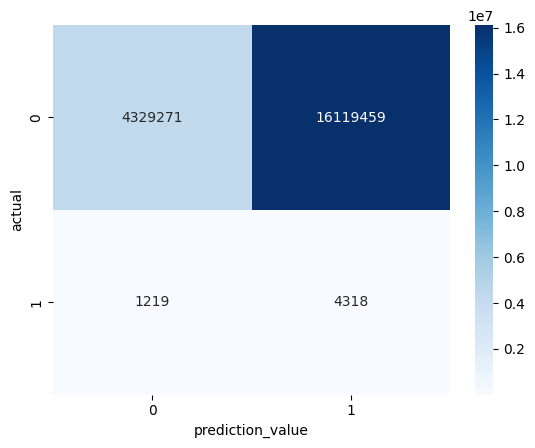

In [276]:
# confusion matrix
confusion_matrix = pd.crosstab(baseline_error["actual"], baseline_error["prediction_value"])

# draw confusion matrix
sns.heatmap(confusion_matrix, annot=True, fmt="d", cmap="Blues")
plt.show()


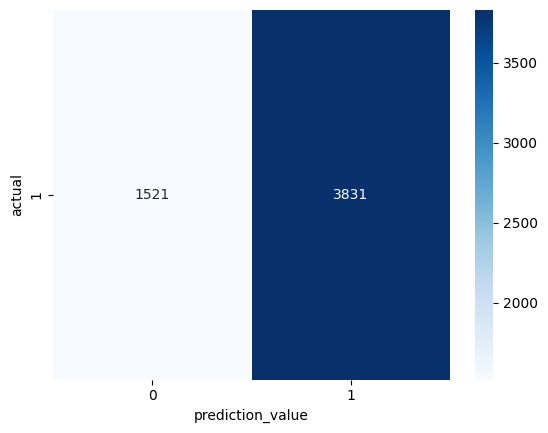

In [283]:
baseline_error_test = pd.merge(baseline_error, df_test, left_on=["user_id", "item_id"], right_on=["user_id", "parent_asin"], how="inner")
baseline_error_test['__temp_is_rating_nan__'] = baseline_error_test['rating'].isna()

baseline_error_test = baseline_error_test.sort_values(
    by=['user_id', 'item_id', '__temp_is_rating_nan__'],
    ascending=[True, True, True] 
)
baseline_error_test = baseline_error_test.drop_duplicates(subset=['user_id', 'item_id'], keep='first')
baseline_error_test["actual"] = 1

# Remove the temporary column.
baseline_error_test = baseline_error_test.drop(columns=['__temp_is_rating_nan__'])
confusion_matrix_test = pd.crosstab(baseline_error_test["actual"], baseline_error_test["prediction_value"])
sns.heatmap(confusion_matrix_test, annot=True, fmt="d", cmap="Blues")
plt.show()


 Interpreting the confusion matrix for the baseline model:
 The matrix shows the trade-offs in the model's predictions.

High False Positives (FP): The model predicts a user will interact with an item (positive prediction), but they didn't (actual negative). A high FP rate is common in recommendation systems. This is largely because the test data only contains a small fraction of all possible items the user *could* have been exposed to. An 'actual negative' often just means 'no interaction recorded', not 'disliked'. The model might correctly identify an item matching the user's preferences, but if the user never saw it or interacted with it in the limited history available in the test set, it gets counted as an FP.

True Positives (TP) vs. False Negatives (FN): The model achieved 944 True Positives, correctly identifying items the user interacted with. This needs to be compared with False Negatives (290) – items the user interacted with but the model failed to predict. A higher TP compared to FN indicates the model is learning signals about user preferences and can recall items the user genuinely likes. The ratio of TP (944) to FP (290) suggests the model is more likely to be correct than incorrect when predicting a positive interaction. Overall, while the FP rate highlights the challenge of implicit feedback, the TP count suggests the model is capturing some understanding of user preferences.


### **2.2 LLM-COL-HIERARCHY-TAX (gemma3)**

In [240]:
MODEL_TECHNIQUE = MODEL_TECHNIQUES[3]
MODEL_TECHNIQUE_NAME = MODEL_TECHNIQUE.replace("/", "_")


EXPERIMENT_NAME = "#1"
EXPERIMENT_DATA_PATH = os.path.join(project_root,"data","experiments",EXPERIMENT_NAME,DATASET,MODEL_TECHNIQUE)

gemma_error = pd.read_csv(f"{EXPERIMENT_DATA_PATH}/predictions.csv") # contains the predictions
gemma_mapping = pd.read_csv(f"{EXPERIMENT_DATA_PATH}/entity_map.csv") # to convert ids to entity names
gemma_relation = pd.read_csv(f"{TAXONOMY_PATH}/{MODEL_TECHNIQUE_NAME}_taxonomy.csv") # contains the relations between items and hierarhcy


In [241]:

gemma_error = process_prediction(gemma_error)
gemma_error = count_hits(gemma_error)

Accuracy in test set: 0.2158864323685972


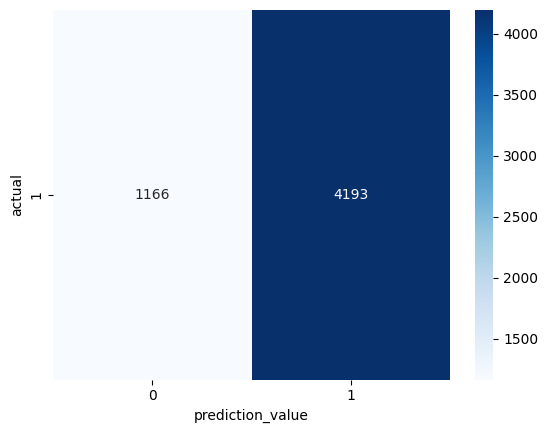

In [282]:

sns.heatmap(confusion_matrix_test, annot=True, fmt="d", cmap="Blues")
plt.show()


Compared to baseline we observe for the top 20 prediciton and test set an noticable increase in true positives. This indicates that the LLM-COL-HIERARCHY-TAX model is better at identifying items the user interacted with.

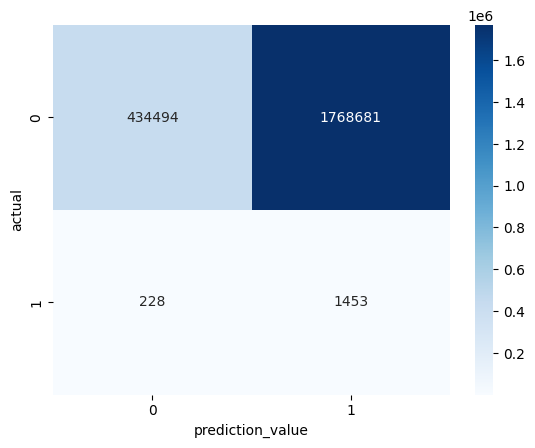

In [224]:
# confusion matrix
confusion_matrix = pd.crosstab(gemma_error["actual"], gemma_error["prediction_value"])

# draw confusion matrix
sns.heatmap(confusion_matrix, annot=True, fmt="d", cmap="Blues")
plt.show()


Actual values in top K predictions:  actual
0    16228
1       32
Name: count, dtype: int64
Accuracy in test set: 0.0019680196801968018


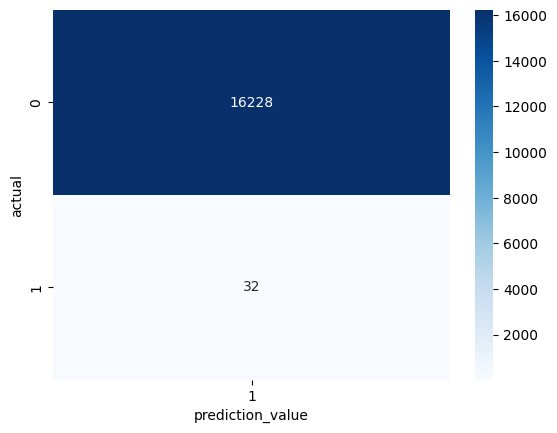

In [225]:
gemma_relation = pd.read_csv(f"{TAXONOMY_PATH}/{MODEL_TECHNIQUE_NAME}_taxonomy.csv") # contains the relations between items and hierarhcy
gemma_error_at_k = gemma_error.sort_values(by=["user_id","prediction"], ascending=True)
gemma_error_at_k = gemma_error_at_k.groupby("user_id").tail(20)
print("Actual values in top K predictions: ",gemma_error_at_k["actual"].value_counts())
gemma_error_at_k = process_prediction(gemma_error_at_k)
gemma_error_at_k = count_hits(gemma_error_at_k)
gemma_error_at_k
# confusion matrix
confusion_matrix = pd.crosstab(gemma_error_at_k["actual"], gemma_error_at_k["prediction_value"])

# draw confusion matrix
sns.heatmap(confusion_matrix, annot=True, fmt="d", cmap="Blues")
plt.show()


The confusion matrix for the KG model with the LLM-COL-HIERARCHY-TAX created by gemma3-3b shows the following results:
 * True Positives (TP): 1.453
 * False Positives (FP): 228
 * True Negatives (TN): 1.768.681
 * False Negatives (FN): 434494
 

Comparing these results to the baseline model:
 * There is a notable jump in True Positives compared to the baseline, indicating the LLM-COL-HIERARCHY-TAX model identifies more actual positive interactions.
 * Simultaneously, there is a noticable incline in False Negatives. This suggests that while the model may be learning user preferences or item relationships from the taxonomy (contributing to higher TP), it also leads to incorrectly classifying a larger number of negative interactions as positive. Due to this observation the true negative rate drops aswell.


To observe the errors and identify patterns we want to look for an item entity all the relations in the taxonomy that are connected to it.

In [208]:
gemma_error_item = connect_parents(gemma_error, gemma_relation)

In [209]:
gemma_error_item["fourth_level_parent"].value_counts()

Series([], Name: count, dtype: int64)

Taxonomy only three levels deep

In [210]:
df_train["item_id"] = df_train["parent_asin"]
df_train_parents = connect_parents(df_train, gemma_relation)

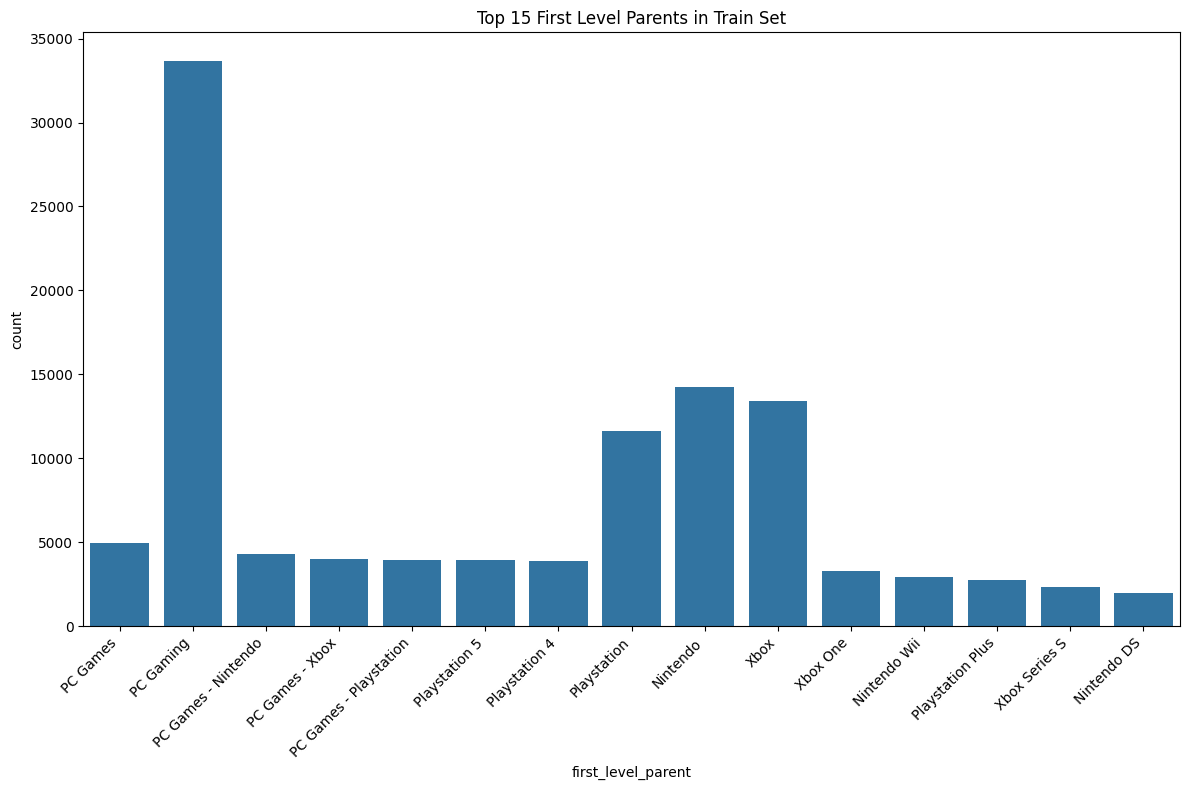

In [211]:

top_n = 15
# Count unique combinations of user_id, parent_asin, first_level_parent, then count first_level_parent occurrences
top_n_first_level_parents = df_train_parents[['user_id', 'parent_asin', 'first_level_parent']].drop_duplicates()['first_level_parent'].value_counts().nlargest(top_n) 
top_n_first_level_parents = top_n_first_level_parents.index
#plot the first level parents
plt.figure(figsize=(12, 8))

plt.title(f"Top {top_n} First Level Parents in Train Set")
plt.xlabel("first_level_parent")
plt.ylabel("count")
# sort plot by top_n_first_level_parents
sns.countplot(x="first_level_parent", data=df_train_parents, order=top_n_first_level_parents)
plt.xticks(rotation=45, ha='right') # Adjust rotation for readability
plt.tight_layout()
plt.show()

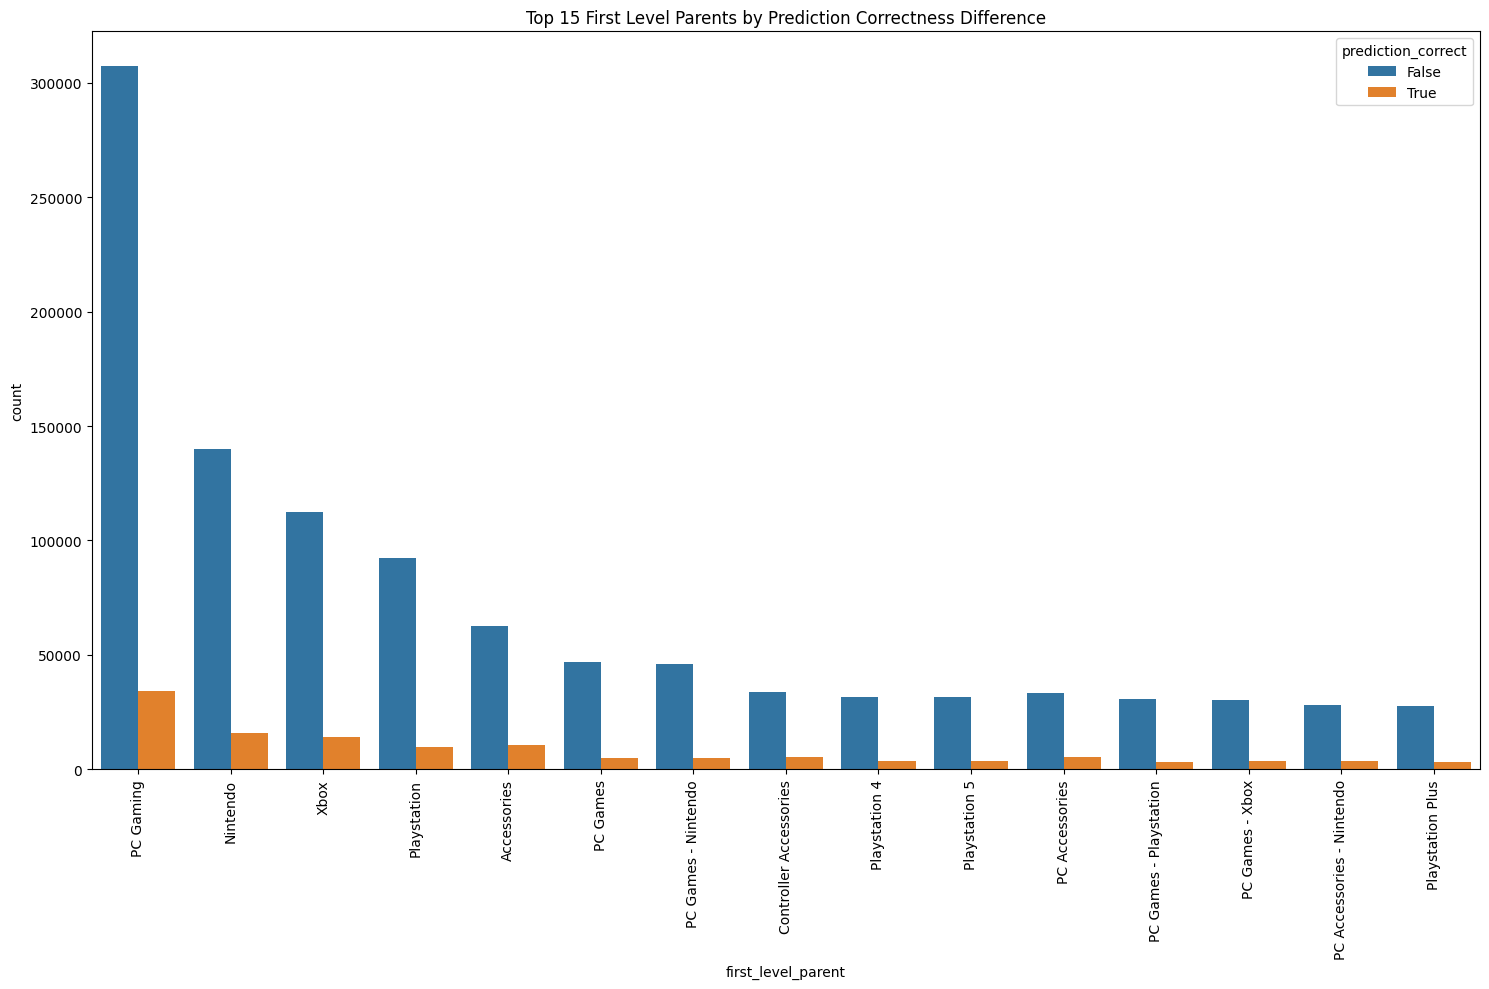

In [134]:
# Calculate counts for each combination of second_level_parent and prediction_correct
counts_first = gemma_error_item.groupby(['first_level_parent', 'prediction_correct']).size().unstack(fill_value=0)

# Ensure both True and False columns exist
if True not in counts_first.columns:
    counts_first[True] = 0
if False not in counts_first.columns:
    counts_first[False] = 0

# Calculate the absolute difference between True and False counts
counts_first['difference'] = abs(counts_first[True] - counts_first[False])

# Get the top N second_level_parent categories with the biggest difference (e.g., top 15)
top_n = 15
top_parents_first = counts_first.nlargest(top_n, 'difference').index

# Filter the original dataframe to include only these top N categories
filtered_data_first = gemma_error_item[gemma_error_item['first_level_parent'].isin(top_parents_first)]

# Plot the results for the top N categories
plt.figure(figsize=(15, 10)) # Adjust figure size if needed
plt.title(f"Top {top_n} First Level Parents by Prediction Correctness Difference")
plt.xlabel("first_level_parent")
plt.ylabel("count")
sns.countplot(x="first_level_parent", hue="prediction_correct",
              data=filtered_data_first, order=top_parents_first) # Order bars by difference magnitude
plt.xticks(rotation=90) # Keep rotation for potentially long labels
plt.tight_layout()
plt.show()

In [135]:
# Convert the indices to sets for easier comparison
set_top_parents_first = set(top_parents_first)
set_top_n_first_level_parents_train = set(top_n_first_level_parents)

# Find the intersection
common_parents = set_top_parents_first.intersection(set_top_n_first_level_parents_train)

# Count the number of common parents
num_common_parents = len(common_parents)

print(f"Number of first_level_parents common between the top {top_n} by prediction difference and top {top_n} by frequency in train set: {num_common_parents}")
print("Common parents:", common_parents)


Number of first_level_parents common between the top 15 by prediction difference and top 15 by frequency in train set: 10
Common parents: {'PC Games - Xbox', 'PC Games - Nintendo', 'PC Games - Playstation', 'Playstation 5', 'Playstation', 'Xbox', 'Playstation 4', 'PC Games', 'PC Gaming', 'Nintendo'}


The analysis of the training data reveals that items associated with top-level categories like 'nintendo', 'pc gaming', and 'xbox' are significantly more represented. Correspondingly, the error analysis on the test set indicates that predictions for items directly linked to these highly frequent parent entities exhibit a notably higher error margin. Which might indicate that the model is overfitting to the most frequent parent entities.


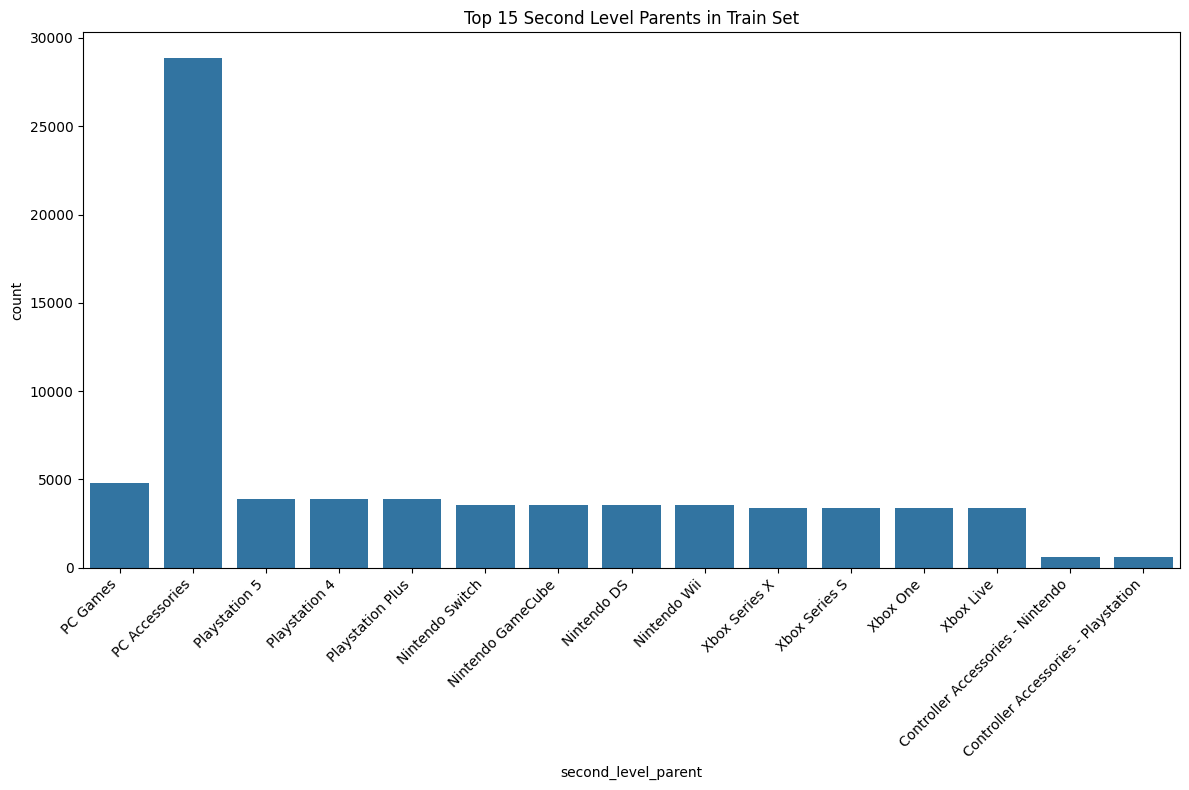

In [136]:

top_n = 15
# Count unique combinations of user_id, parent_asin, first_level_parent, then count first_level_parent occurrences
top_n_second_level_parents = df_train_parents[['user_id', 'parent_asin', 'second_level_parent']].drop_duplicates()['second_level_parent'].value_counts().nlargest(top_n) 
top_n_second_level_parents = top_n_second_level_parents.index
#plot the first level parents
plt.figure(figsize=(12, 8))

plt.title(f"Top {top_n} Second Level Parents in Train Set")
plt.xlabel("second_level_parent")
plt.ylabel("count")
# sort plot by top_n_first_level_parents
sns.countplot(x="second_level_parent", data=df_train_parents, order=top_n_second_level_parents)
plt.xticks(rotation=45, ha='right') # Adjust rotation for readability
plt.tight_layout()
plt.show()

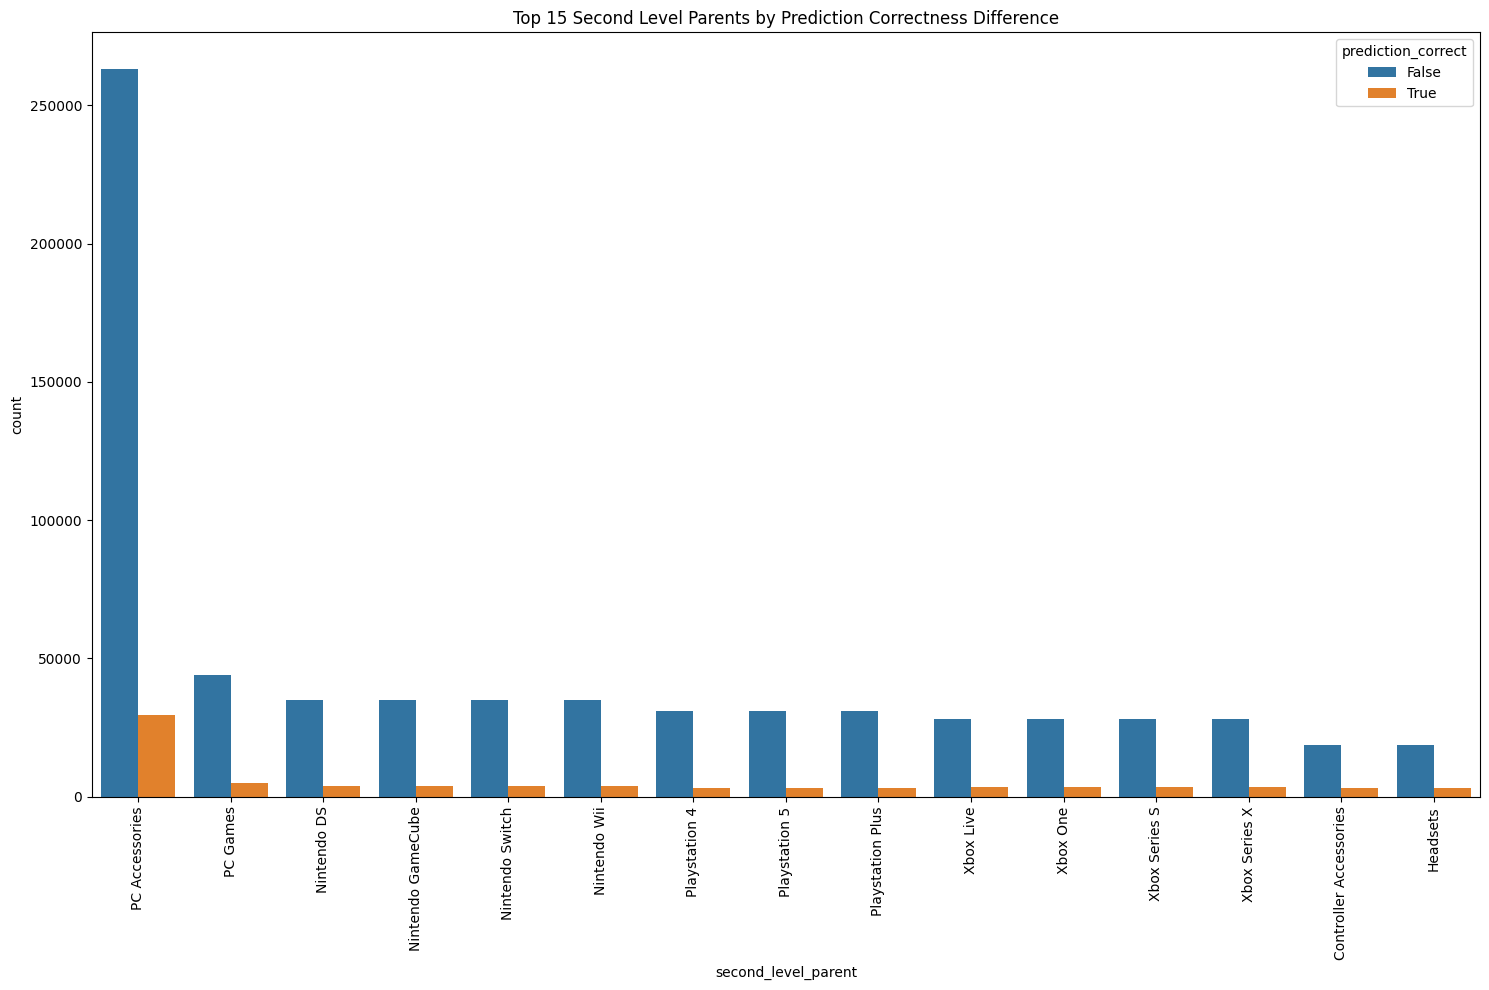

In [137]:
# Calculate counts for each combination of second_level_parent and prediction_correct
counts_second = gemma_error_item.groupby(['second_level_parent', 'prediction_correct']).size().unstack(fill_value=0)

# Ensure both True and False columns exist
if True not in counts_second.columns:
    counts_second[True] = 0
if False not in counts_second.columns:
    counts_second[False] = 0

# Calculate the absolute difference between True and False counts
counts_second['difference'] = abs(counts_second[True] - counts_second[False])

# Get the top N second_level_parent categories with the biggest difference (e.g., top 15)
top_n = 15
top_parents_second = counts_second.nlargest(top_n, 'difference').index

# Filter the original dataframe to include only these top N categories
filtered_data_second = gemma_error_item[gemma_error_item['second_level_parent'].isin(top_parents_second)]

# Plot the results for the top N categories
plt.figure(figsize=(15, 10)) # Adjust figure size if needed
plt.title(f"Top {top_n} Second Level Parents by Prediction Correctness Difference")
plt.xlabel("second_level_parent")
plt.ylabel("count")
sns.countplot(x="second_level_parent", hue="prediction_correct",
              data=filtered_data_second, order=top_parents_second) # Order bars by difference magnitude
plt.xticks(rotation=90) # Keep rotation for potentially long labels
plt.tight_layout()
plt.show()

In [138]:
# Convert the indices to sets for easier comparison
set_top_parents_second = set(top_parents_second)
set_top_n_second_level_parents_train = set(top_n_second_level_parents)
# Find the intersection
common_parents = set_top_parents_second.intersection(set_top_n_second_level_parents_train)

# Count the number of common parents
num_common_parents = len(common_parents)

print(f"Number of second_level_parents common between the top {top_n} by prediction difference and top {top_n} by frequency in train set: {num_common_parents}")
print("Common parents:", common_parents)


Number of second_level_parents common between the top 15 by prediction difference and top 15 by frequency in train set: 13
Common parents: {'Playstation Plus', 'Xbox Series S', 'PC Accessories', 'Nintendo GameCube', 'Playstation 5', 'Nintendo Wii', 'Nintendo DS', 'Nintendo Switch', 'Xbox Live', 'Playstation 4', 'PC Games', 'Xbox Series X', 'Xbox One'}


For the second level its visible that in train set items associated to Nintendo Switch and Controllers are overrepresented. This items have a high error margin. Additionally other well represented associated categories are  under the top 15 represented items and have a high error margin. This indicates that the model if looking at the second level parent is highly biased towards popular items.


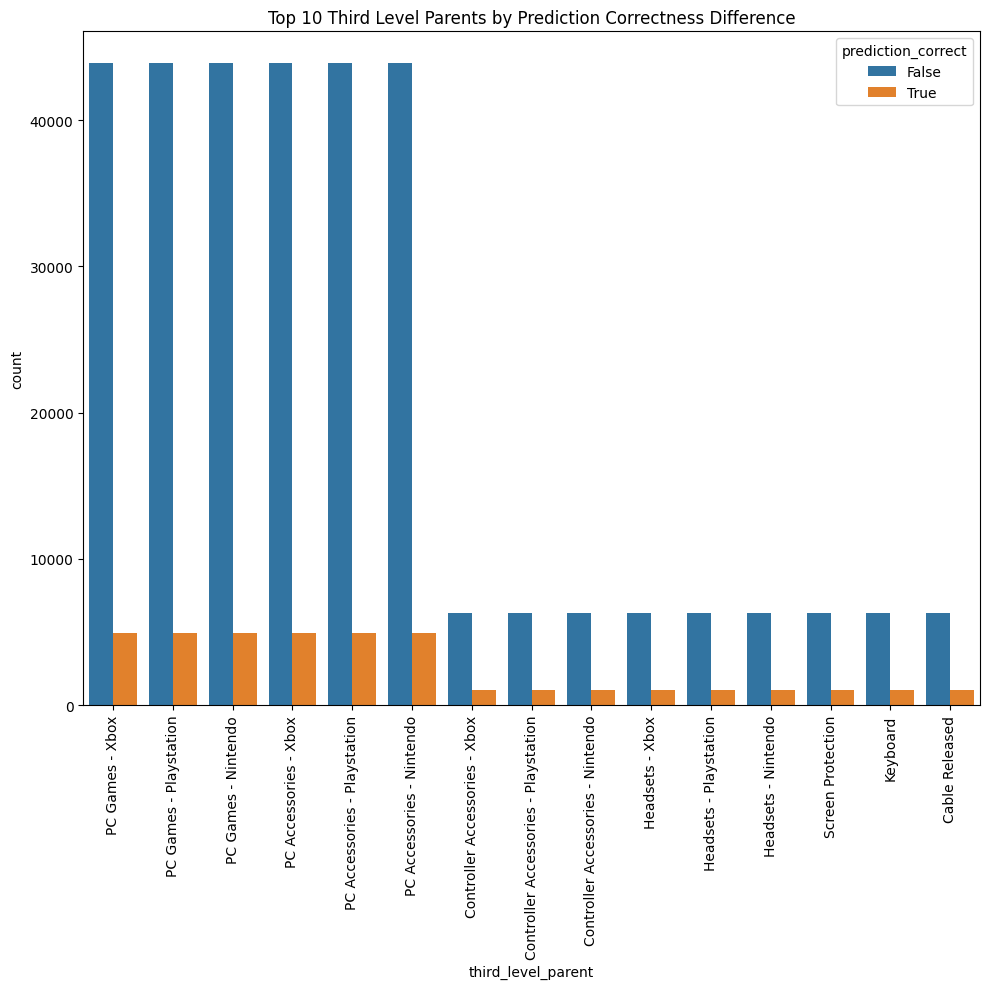

In [139]:
# third level parent
# Calculate counts for each combination of second_level_parent and prediction_correct
counts_third = gemma_error_item.groupby(['third_level_parent', 'prediction_correct']).size().unstack(fill_value=0)

# Ensure both True and False columns exist
if True not in counts_third.columns:
    counts_third[True] = 0
if False not in counts_third.columns:
    counts_third[False] = 0

# Calculate the absolute difference between True and False counts
counts_third['difference'] = abs(counts_third[True] - counts_third[False])

# Get the top N second_level_parent categories with the biggest difference (e.g., top 15)
top_n = 15
top_parents_third = counts_third.nlargest(top_n, 'difference').index
filtered_data_third = gemma_error_item[gemma_error_item['third_level_parent'].isin(top_parents_third)]

plt.figure(figsize=(10, 10))
plt.title("Top 10 Third Level Parents by Prediction Correctness Difference")
plt.xlabel("third_level_parent")
plt.ylabel("count")
sns.countplot(x="third_level_parent", hue="prediction_correct", data=filtered_data_third)
plt.xticks(rotation=90) # Keep rotation for potentially long labels
plt.tight_layout() # Apply tight layout similar to the previous plot
plt.show()

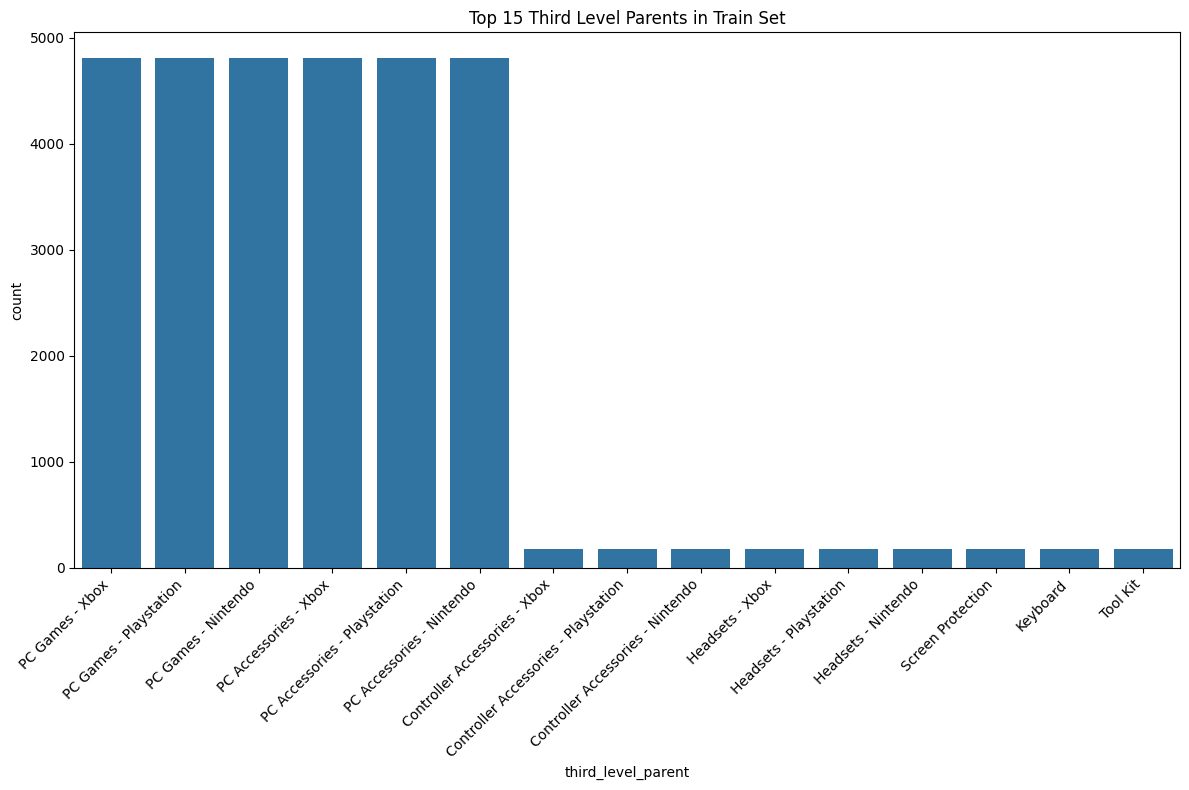

In [140]:

top_n = 15
top_n_third_level_parents = df_train_parents["third_level_parent"].value_counts().nlargest(top_n).index

#plot the first level parents
plt.figure(figsize=(12, 8))

plt.title(f"Top {top_n} Third Level Parents in Train Set")
plt.xlabel("third_level_parent")
plt.ylabel("count")
sns.countplot(x="third_level_parent", data=df_train_parents, order=top_n_third_level_parents)
plt.xticks(rotation=45, ha='right') # Adjust rotation for readability
plt.tight_layout()
plt.show()

In [141]:
# common parents
set_top_parents_third = set(top_parents_third)
set_top_n_third_level_parents_train = set(top_n_third_level_parents)
common_parents = set_top_parents_third.intersection(set_top_n_third_level_parents_train)
num_common_parents = len(common_parents)
print(f"Number of third_level_parents common between the top {top_n} by prediction difference and top {top_n} by frequency in train set: {num_common_parents}")
print("Common parents:", common_parents)


Number of third_level_parents common between the top 15 by prediction difference and top 15 by frequency in train set: 14
Common parents: {'PC Games - Xbox', 'PC Games - Nintendo', 'Controller Accessories - Playstation', 'PC Games - Playstation', 'Controller Accessories - Xbox', 'PC Accessories - Nintendo', 'Controller Accessories - Nintendo', 'Headsets - Xbox', 'PC Accessories - Playstation', 'Headsets - Nintendo', 'PC Accessories - Xbox', 'Headsets - Playstation', 'Keyboard', 'Screen Protection'}


The third level parents represantion is similiar to first and second level parents. 13 out of 15 commom third level parents with high error margin are also in top 15 of the train set. Indicating that the model is biased towards popular items.


In [142]:
gemma_error_item.head()
wrong_prediction = pd.DataFrame(gemma_error_item[gemma_error_item["prediction_correct"] == False])
wrong_prediction 

,user_id,item_id,prediction,actual,prediction_sigmoid,prediction_value,prediction_correct,prediction_positive,prediction_negative,first_level_parent,second_level_parent,third_level_parent,fourth_level_parent
530,AE23PXMECDNZRSKAQV6CAIEN67UQ,B0BNQRW8RC,0.004899,0,0.501225,1,False,True,False,NaN,NaN,NaN,NaN
531,AE23PXMECDNZRSKAQV6CAIEN67UQ,B0BP9FLPD1,0.007408,0,0.501852,1,False,True,False,NaN,NaN,NaN,NaN
532,AE23PXMECDNZRSKAQV6CAIEN67UQ,B01MCQC13K,0.010441,0,0.502610,1,False,True,False,NaN,NaN,NaN,NaN
533,AE23PXMECDNZRSKAQV6CAIEN67UQ,B094HH5WQB,0.010737,0,0.502684,1,False,True,False,NaN,NaN,NaN,NaN
534,AE23PXMECDNZRSKAQV6CAIEN67UQ,B000LSKXRQ,0.015462,0,0.503865,1,False,True,False,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3679633,AHZRZBDZXNMGNKBMCOTBMQAZMQ5Q,B0BMXG1V9T,0.060696,0,0.515169,1,False,True,False,NaN,NaN,NaN,NaN
3679634,AHZRZBDZXNMGNKBMCOTBMQAZMQ5Q,B0C8C8LC6K,0.060861,0,0.515210,1,False,True,False,NaN,NaN,NaN,NaN
3679635,AHZRZBDZXNMGNKBMCOTBMQAZMQ5Q,B0BNKQDQS7,0.061165,0,0.515286,1,False,True,False,NaN,NaN,NaN,NaN
3679636,AHZRZBDZXNMGNKBMCOTBMQAZMQ5Q,B0C2H878MX,0.061631,0,0.515403,1,False,True,False,NaN,NaN,NaN,NaN


To understand the systematic error we want to look at the Subgraph of items that has the highest error margin.

In [143]:
wrong_prediction_item = df_metadata[df_metadata["parent_asin"] == wrong_prediction["item_id"].tail(1).iloc[0]]
wrong_prediction_item = wrong_prediction_item["parent_asin"].iloc[0]


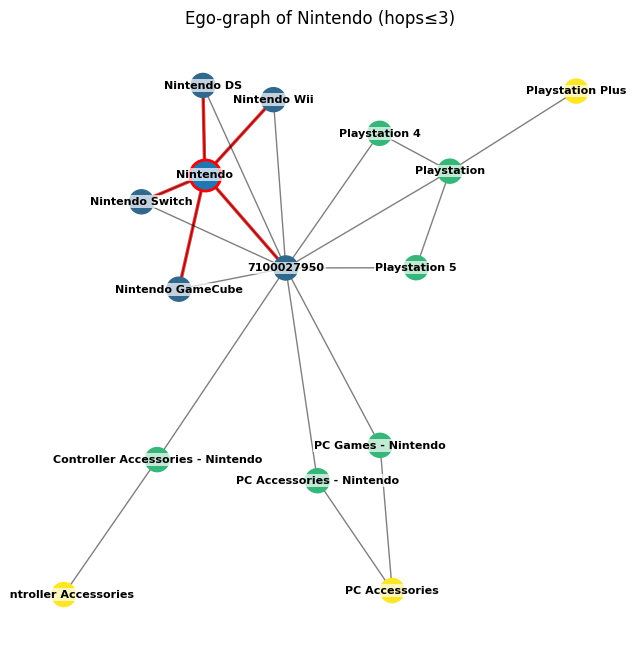

In [154]:
gemma_relation_wo_products = gemma_relation[
    (~gemma_relation["head"].str.startswith("B0") | gemma_relation["head"].str.contains(wrong_prediction_item)) &
    ~gemma_relation["head"].str.startswith("A")
]
g_taxonomy = nx.from_pandas_edgelist(gemma_relation_wo_products, source='head', target='tail')

draw_ego_hops(g_taxonomy, center_node="Nintendo", hops=3)

In [145]:
# filter out item 7100027950
print(df_metadata[df_metadata["parent_asin"] == "7100027950"]["source_text"].iloc[0]) 


Parent ASIN: 7100027950; Title: The Legend of Zelda: The Wind Waker; Author: *; Description: Description: 'Product Description', Continue Link's adventures with Legend of Zelda: The Wind Waker. You'll experience sword-swinging action, perplexing puzzles and stirring storylines. The trouble starts when Link witnesses his sister being snatched up by a giant bird. He then embarks on an epic voyage to locate his sister., 'Amazon.com', 'The', 'Legend of Zelda', 'series practically defined adventure gaming for an entire generation. Link, the hero of the adventure games, delighted millions by starring in games for each Nintendo console from the NES and Super NES to the Nintendo 64. Link brings this beloved franchise to the Nintendo GameCube in', 'The Legend Of Zelda: The Wind Waker', , and he's more, 'animated', 'than ever.', The first thing you'll notice about, 'The Legend Of Zelda: The Wind Waker', 'is that it looks completely different from any previous title in the franchise. Nintendo has

Looking at the "Nintendo" subgraph, we observe a structural flaw in the taxonomy. Items are often connected directly to both their immediate parent category (e.g., "Nintendo Switch") and also to their grandparent category (e.g., "Nintendo"). This creates redundancies in the graph. For instance, an item related to "Nintendo Switch" might also be directly related to "Nintendo". This means the model might learn redundant or overly broad associations, potentially leading to misclassifications or difficulties in distinguishing fine-grained preferences.

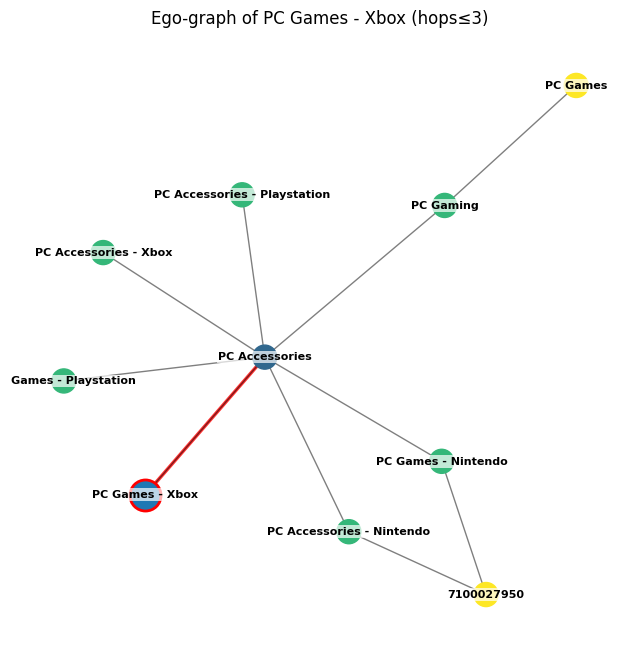

In [146]:
gemma_relation_wo_products = gemma_relation[
    (~gemma_relation["head"].str.startswith("B0") | gemma_relation["head"].str.contains(wrong_prediction_item)) & 
    ~gemma_relation["head"].str.startswith("A")
]

g_taxonomy = nx.from_pandas_edgelist(gemma_relation_wo_products, source='head', target='tail') 
draw_ego_hops(g_taxonomy, center_node="PC Games - Xbox", hops=3)

In [147]:
gemma_relation_wo_products = gemma_relation[
    (~gemma_relation["head"].str.startswith("B0") | gemma_relation["head"].str.contains(wrong_prediction_item)) & 
    ~gemma_relation["head"].str.startswith("A")
]

g_taxonomy = nx.from_pandas_edgelist(gemma_relation_wo_products, source='head', target='tail') 
#draw_ego_hops(g_taxonomy, center_node="PC Games - Playstation", hops=2)
draw_ego_hops(g_taxonomy, center_node="VR Headsets", hops=2)

NodeNotFound: Source VR Headsets is not in G

Looking at deeper levels of the taxonomy we detect multiple irregeluarities. First we notice that the childs (third level parents) of "Nintendo" and "Games" are directly connected to the parent "Hardware". Logically there might be a missing parent "Software" to connect the childs more clear. This would give for instance wider seperation between the categories like "Software" or "Playstation" and build clearer preferences. Also the item "9625990674" is connected to a lot of parents with confussing logics. It is aswell associated to the consoles "PC Games", "Nintnedo", and multiple Nintendo consoles. How is this possible? As of right now links from items to the taxonomy are made if a keyword of the items description has a cosine simliarity threshold of 0.5. This is a very low threshold and might be the reason why the model is confused. 

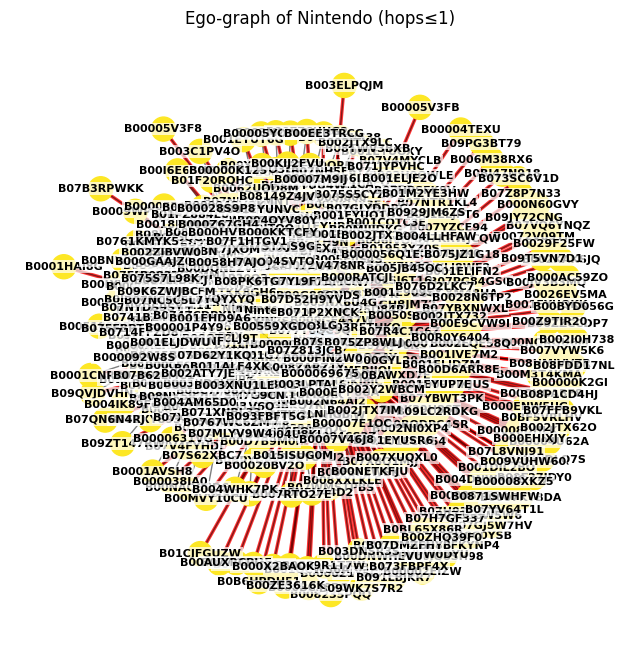

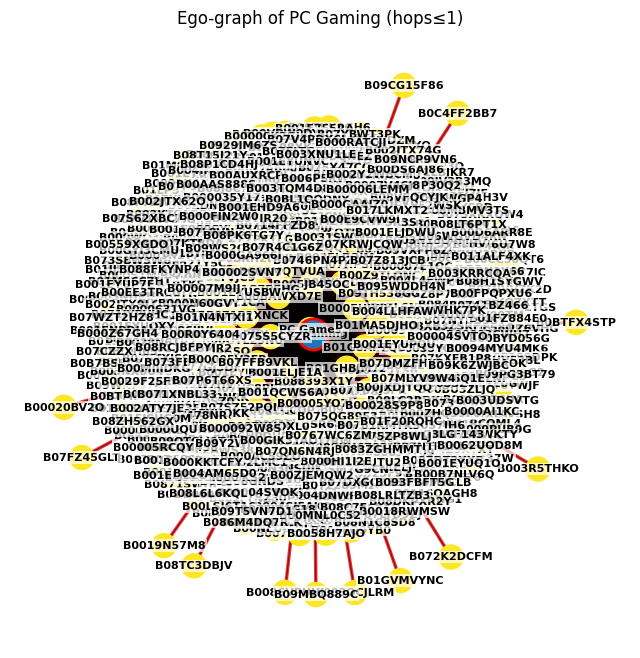

In [150]:
g_tax_items = nx.from_pandas_edgelist(gemma_relation, source='head', target='tail')
draw_ego_hops(g_tax_items, center_node="Nintendo", hops=1)

draw_ego_hops(g_tax_items, center_node="PC Gaming", hops=1)


With the sheer load of items and relations looking at the graph its hard to detect traversable redundancies. But we can see that the higher level categories "PC Gaming", "Nintendo" is connected to a lot of items. This is likely the reason why the model predicts a lot of items as positive, which are actually negative. To test this hypothesis we calculate the number of items that are connected to multiple parents and the percantegage of items that are redundantly connected to multiple parents.

For redundancy detection we now look how many items are connected to a specific parent and second level parent.

In [49]:
# Assuming gemma_relation (pd.DataFrame) and g_tax (nx.DiGraph) are loaded from previous cells.
# g_tax: edges represent parent -> child relationship ('is parent of')
print("# Unique relationships: ", len(gemma_relation.drop_duplicates()))

print("\nDetecting redundancies: Items linked to both a taxonomy node and its parent...")

# 1. Filter item relations (head is item ID starting with B0, relation is 'related to', tail is taxonomy node)
# Added check to exclude potential user IDs like 'B0...' followed by '_'
item_relations = gemma_relation[
    (gemma_relation['head'].str.startswith('B0', na=False)) &
    (gemma_relation['relation'] == 'related to') &
    (~gemma_relation['head'].str.contains('_', na=False))
].copy() # Use .copy() to avoid SettingWithCopyWarning if modifying later

# Ensure tail nodes are strings (taxonomy nodes)
item_relations['tail'] = item_relations['tail'].astype(str)

# 2. Group related taxonomy nodes by item
# Use .dropna() in case some items have no relations after filtering
item_groups = item_relations.groupby('head')['tail'].apply(set).dropna()

# 3. Detect redundancies
redundancies_found = []
redundancy_details = defaultdict(list) # Store details: {item: [(parent, child), ...]}

print(f"Checking {len(item_groups)} items with multiple taxonomy links...")

# Check if g_tax exists and is a graph
if 'g_tax_items' not in locals() or not isinstance(g_tax_items, nx.Graph):
    print("Error: Taxonomy graph 'g_tax_items' not found or is not a NetworkX graph.")
    # Handle error appropriately, maybe raise exception or exit
else:
    processed_items = 0
    for item, related_nodes in item_groups.items():
        if len(related_nodes) < 2:
            continue # Need at least two related nodes to have a redundancy

        nodes_list = list(related_nodes)
        item_has_redundancy = False
        # Iterate through all unique pairs of related nodes for the item
        for i in range(len(nodes_list)):
            for j in range(i + 1, len(nodes_list)):
                node1 = nodes_list[i]
                node2 = nodes_list[j]

                # Ensure both nodes exist in the taxonomy graph before checking edges
                if node1 in g_taxonomy and node2 in g_taxonomy:
                    # Check if node1 is parent of node2 in g_tax
                    if g_taxonomy.has_edge(node1, node2):
                        redundancy = (item, node1, node2) # (item, parent, child)
                        # Check for duplicates before adding
                        if (node1, node2) not in redundancy_details[item]:
                             redundancy_details[item].append((node1, node2))
                             item_has_redundancy = True

                    # Check if node2 is parent of node1 in g_tax
                    elif g_taxonomy.has_edge(node2, node1):
                         redundancy = (item, node2, node1) # (item, parent, child)
                         # Check for duplicates before adding
                         if (node2, node1) not in redundancy_details[item]:
                             redundancy_details[item].append((node2, node1))
                             item_has_redundancy = True

        if item_has_redundancy:
            processed_items += 1
            # Collect all unique redundancy tuples (item, parent, child)
            for parent, child in redundancy_details[item]:
                 redundancies_found.append((item, parent, child))


    # 4. Report results
    print(f"\nFinished checking. Found {len(redundancies_found)} redundant relationships across {len(redundancy_details)} items.")
    print(f"% of # relationsships are redundant: {round(len(redundancies_found) / len(gemma_relation) * 100, 2)}") 
    print(f"% of # items with multiple relationsships have redundancies: {round(len(redundancy_details) / len(item_groups) * 100, 2)}") 
    print(f"A redundant relationship means an item is linked to both a parent node and its child node in the taxonomy.")

    # Print some examples
    if redundancies_found:
        print("\nExamples of redundant links (Item, Parent, Child):")
        limit = min(10, len(redundancies_found))
        for i in range(limit):
            item, parent, child = redundancies_found[i]
            print(f"- Item: {item}, Parent: {parent}, Child: {child}")
        if len(redundancies_found) > limit:
            print(f"... and {len(redundancies_found) - limit} more.")

        # Optional: Analyze which parent-child pairs appear most often in redundancies
        parent_child_counts = defaultdict(int)
        for item_redundancies_list in redundancy_details.values():
            for parent, child in item_redundancies_list:
                parent_child_counts[(parent, child)] += 1

        print("\nMost common redundant parent-child pairs:")
        # Sort by count descending
        sorted_pairs = sorted(parent_child_counts.items(), key=lambda pc_item: pc_item[1], reverse=True)
        limit = min(10, len(sorted_pairs))
        for i in range(limit):
            (parent, child), count = sorted_pairs[i]
            print(f"- ({parent}, {child}): Found for {count} items")
        if len(sorted_pairs) > limit:
             print(f"... and {len(sorted_pairs) - limit} more pairs.")
    else:
        print("\nNo redundant relationships found.")


# Unique relationships:  24103

Detecting redundancies: Items linked to both a taxonomy node and its parent...
Checking 2650 items with multiple taxonomy links...

Finished checking. Found 12788 redundant relationships across 2342 items.
% of # relationsships are redundant: 53.06
% of # items with multiple relationsships have redundancies: 88.38
A redundant relationship means an item is linked to both a parent node and its child node in the taxonomy.

Examples of redundant links (Item, Parent, Child):
- Item: B00000DMAR, Parent: Games, Child: Xbox Games
- Item: B00000DMAU, Parent: Nintendo Games, Child: Games
- Item: B00000DMAU, Parent: PlayStation 5, Child: PlayStation
- Item: B00000DMAU, Parent: PlayStation 4, Child: PlayStation
- Item: B00000DMAU, Parent: Xbox Games, Child: Games
- Item: B00000DMAU, Parent: Games, Child: PlayStation Games
- Item: B00000DMAU, Parent: Xbox One, Child: Xbox
- Item: B00000DMAU, Parent: PlayStation, Child: PlayStation Vita
- Item: B00000IJVY, Parent: Pla

Observable that 53% of relations are redundant. To be more precised items thatt are multiple connected have 88% redundant relationsships to parents. Therefore we remove redundancies. We use two approaches. First bottom up approach. This removes all relations from items to grand parents or further up. This method forces GNN KG to obtain more fine-grained information. Second top down approach. This removes all relations from items to parents. This method forces GNN KG to obtain more coarse-grained information.

In [50]:
from collections import defaultdict
import pandas as pd
import networkx as nx

print("Building graph from relations DataFrame...")
G_relations = nx.DiGraph()
for _, row in gemma_relation.iterrows():
    h_str = str(row['head'])
    t_str = str(row['tail'])
    G_relations.add_edge(h_str, t_str)
print(f"Graph built with {G_relations.number_of_nodes()} nodes and {G_relations.number_of_edges()} edges.")



def filter_redundant_direct_relations(relations_df, taxonomy_graph):
    """
    Filters redundant relationships from a DataFrame of item-category links.

    A relationship (item, category) is considered redundant if the item is also
    linked to a direct parent of that category within the provided taxonomy graph.
    This function identifies such redundant rows in the input DataFrame and returns
    a new DataFrame with these rows removed.

    Args:
        relations_df (pd.DataFrame): DataFrame with at least 'head' (item or taxonomy category)
                                     and 'tail' (category) columns, representing the links.
        taxonomy_graph (nx.DiGraph): A networkx directed graph representing the
                                     category taxonomy, where an edge (u, v)
                                     means u is a direct parent of v. This graph is used
                                     as a reference to define redundancy but is not modified.

    Returns:
        pd.DataFrame: A new DataFrame containing only the non-redundant relationships
                      from the original relations_df.
    """
    # Step 1: Group relations by item ('head') to process each item's links together.
    # This allows checking for redundancies within the set of categories linked to a single item.
    grouped = relations_df.groupby('head')

    # Step 2: Initialize a set to store the indices of rows in the DataFrame to be removed.
    # Using a set avoids duplicates efficiently if multiple parent-child pairs point
    # to the same redundant row index.
    redundant_indices = set()

    # Step 3: Iterate through each item and its associated category links (rows in the group).
    for item, group in grouped:
        # Get the unique categories linked to this specific item from the 'tail' column.
        categories = group['tail'].unique().tolist()

        # Step 4: Check for redundancy only if the item is linked to more than one category.
        # If an item links to only one category, it cannot be redundant according to the
        # definition (requires links to both parent and child).
        if len(categories) > 1:
            # Step 5: Iterate through all unique pairs of categories linked to this item.
            # itertools.combinations ensures each pair is checked only once.
            for cat1, cat2 in itertools.combinations(categories, 2):
                # Step 6: Check if an ancestor-descendant relationship exists between the pair
                #         of categories in the provided taxonomy graph. An item linked to both
                #         an ancestor and a descendant category has a redundant link to the descendant.

                # Ensure both categories exist as nodes in the graph before checking ancestry.
                if cat1 in taxonomy_graph and cat2 in taxonomy_graph:
                    # Check if cat1 is an ancestor of cat2 (path exists from cat1 to cat2).
                    # nx.ancestors(graph, node) returns all nodes from which 'node' is reachable.
                    if cat1 in nx.ancestors(taxonomy_graph, cat2):
                        # If cat1 is an ancestor of cat2, the link from the item to the descendant (cat2)
                        # is considered redundant because a link to the ancestor (cat1) also exists.
                        # Find the original DataFrame index/indices corresponding to the (item, cat2) link(s)
                        # within this item's group.
                        idx_to_remove = group[group['tail'] == cat2].index
                        # Add these indices to the set of redundant indices.
                        redundant_indices.update(idx_to_remove)

                    # Check if cat2 is an ancestor of cat1 (path exists from cat2 to cat1).
                    elif cat2 in nx.ancestors(taxonomy_graph, cat1):
                        # If cat2 is an ancestor of cat1, the link from the item to the descendant (cat1)
                        # is considered redundant because a link to the ancestor (cat2) also exists.
                        # Find the original DataFrame index/indices corresponding to the (item, cat1) link(s)
                        # within this item's group.
                        idx_to_remove = group[group['tail'] == cat1].index
                        # Add these indices to the set of redundant indices.
                        redundant_indices.update(idx_to_remove)

    # Step 7: Create the filtered DataFrame by removing the rows corresponding to the
    # identified redundant indices from the original DataFrame.
    print(f"Identified {len(redundant_indices)} redundant relationships (rows) to remove from the DataFrame.")
    # Convert the set of indices to a list for the .drop() method.
    # reset_index(drop=True) creates a new default index for the filtered DataFrame.
    filtered_df = relations_df.drop(index=list(redundant_indices)).reset_index(drop=True)

    # Print comparison of sizes and the head of the filtered DataFrame
    print(f"Original relations DataFrame size: {len(relations_df)}")
    print(f"Filtered relations DataFrame size: {len(filtered_df)}")
    print("\nHead of the filtered DataFrame:")

    # Step 8: Return the DataFrame with redundant relationship rows removed.
    return filtered_df



Building graph from relations DataFrame...
Graph built with 2682 nodes and 24103 edges.


In [161]:
filtered_direct_relation = filter_redundant_direct_relations(gemma_relation, g_tax_items)
filtered_direct_relation.to_csv(f"{TAXONOMY_PATH}/{MODEL_TECHNIQUE_NAME}_taxonomy-wo-direct-parents.csv")


Identified 7260 redundant relationships (rows) to remove from the DataFrame.
Original relations DataFrame size: 7872
Filtered relations DataFrame size: 612

Head of the filtered DataFrame:


In [183]:
import pandas as pd
from collections import defaultdict

# --- User-Adaptable Helper Function ---
def is_item_node(node_id: str, item_prefixes=("B0", "A0")) -> bool:
    """
    Determines if a node ID represents an item.
    Adapt this function based on how items are identified in your dataset.
    For example, Amazon Standard Identification Numbers (ASINs) often start with "B0" or "A0".

    Args:
        node_id (str): The node identifier.
        item_prefixes (tuple): A tuple of string prefixes that identify item nodes.

    Returns:
        bool: True if the node_id is considered an item, False otherwise.
    """
    if not isinstance(node_id, str):
        return False
    for prefix in item_prefixes:
        if node_id.startswith(prefix):
            return True
    return False
# --- End of User-Adaptable Helper Function ---


def filter_item_to_grandchild_redundancy(relations_df: pd.DataFrame) -> pd.DataFrame:
    """
    Filters out 'item -> grandchild_category' relationships from a DataFrame
    if both 'item -> child_category' and 'child_category -> grandchild_category'
    relationships also exist within the same DataFrame.

    Args:
        relations_df (pd.DataFrame): DataFrame with 'head', 'relation', 'tail' columns.
                                     This DataFrame should contain all relevant links
                                     (item-to-category and category-to-category).

    Returns:
        pd.DataFrame: A new DataFrame with the identified redundant
                      item-to-grandchild_category relationships removed.
    """
    if not isinstance(relations_df, pd.DataFrame):
        raise TypeError("relations_df must be a pandas DataFrame.")
    if not all(col in relations_df.columns for col in ['head', 'tail']):
        raise ValueError("relations_df must contain 'head' and 'tail' columns.")

    # For quick lookups.
    # item_to_direct_categories: maps an item to a set of categories it's directly linked to.
    # category_to_direct_children: maps a category to a set of categories it's a direct parent of.
    item_to_direct_categories = defaultdict(set)
    category_to_direct_children = defaultdict(set)

    # Identify all unique nodes and classify them broadly
    all_nodes = set(relations_df['head']).union(set(relations_df['tail']))
    
    # Heuristic: Nodes not identified as items are considered potential categories.
    # This is a simplification; a more robust system might have explicit node types.
    potential_category_nodes = {node for node in all_nodes if not is_item_node(str(node))}


    # Populate the lookup dictionaries based on node types
    for _, row in relations_df.iterrows():
        h, t = str(row['head']), str(row['tail']) # Ensure string comparison

        if is_item_node(h) and t in potential_category_nodes:
            item_to_direct_categories[h].add(t)
        elif h in potential_category_nodes and t in potential_category_nodes:
            # This is a category -> category link, part of the hierarchy
            category_to_direct_children[h].add(t)
        # Other types of links (e.g., item-to-item) are ignored by this specific filter

    indices_to_drop = set()

    # Iterate through the original DataFrame to check each row for redundancy
    for idx, row in relations_df.iterrows():
        item_candidate = str(row['head'])
        grandchild_category_candidate = str(row['tail'])

        # This filter applies only to 'item -> category' links
        if not (is_item_node(item_candidate) and grandchild_category_candidate in potential_category_nodes):
            continue

        # Let's call them 'item' and 'grandchild_cat' for clarity in this context
        item = item_candidate
        grandchild_cat = grandchild_category_candidate

        # Check if this 'item -> grandchild_cat' link is redundant
        # Need to find a 'child_cat' such that:
        # 1. 'item -> child_cat' exists
        # 2. 'child_cat -> grandchild_cat' exists

        if item in item_to_direct_categories:
            for child_cat in item_to_direct_categories[item]:
                if child_cat == grandchild_cat:
                    # This means the item is directly linked to grandchild_cat,
                    # but child_cat is the same. Not the 3-node path we're looking for.
                    continue

                # Now check if 'child_cat -> grandchild_cat' exists
                if child_cat in category_to_direct_children and \
                   grandchild_cat in category_to_direct_children[child_cat]:
                    
                    # Found the redundant pattern:
                    # item -> child_cat (from item_to_direct_categories)
                    # child_cat -> grandchild_cat (from category_to_direct_children)
                    # current row is item -> grandchild_cat
                    
                    indices_to_drop.add(idx)
                    # Once one such path is found, the current row is redundant.
                    # No need to check other child_cat for this specific row.
                    break
    
    if indices_to_drop:
        print(f"Identified {len(indices_to_drop)} redundant item-to-grandchild relationships to remove.")
        filtered_df = relations_df.drop(index=list(indices_to_drop)).reset_index(drop=True)
    else:
        print("No item-to-grandchild redundant relationships (item -> child -> grandchild pattern) found.")
        filtered_df = relations_df.copy() # Return a copy for consistency

    print(f"Original relations DataFrame size: {len(relations_df)}")
    print(f"Filtered relations DataFrame size: {len(filtered_df)}")
    
    return filtered_df

filtered_item_to_grandchild_relation = filter_item_to_grandchild_redundancy(gemma_relation)


output_filename = f"{TAXONOMY_PATH}/{MODEL_TECHNIQUE_NAME}_taxonomy-wo-grand-parents.csv"
filtered_item_to_grandchild_relation.to_csv(output_filename, index=False)


Identified 3635 redundant item-to-grandchild relationships to remove.
Original relations DataFrame size: 7872
Filtered relations DataFrame size: 4237
